In [1]:
import sys
sys.path.append("..")

In [2]:
import cupy
_ = cupy.cuda.get_local_runtime_version()
sain_runtime = cupy.cuda.runtime

import torch
_ = torch.cuda.is_available()

from gbgpu.gbgpu import GBGPU
cupy.cuda.runtime = sain_runtime

from src.noise import AnalyticNoise
from src.sampling import sample_gb_parameters_uniform

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MultipleLocator

from config import dt, Tobs, f0_center

%load_ext autoreload
%autoreload 2

Dataset will be saved to: data/synthetic_smalltest_gb_dataset as dataset.hdf5


In [3]:
n_samples = 1
seed = 42
parameter_1_waveform, nb_samples, N = sample_gb_parameters_uniform(n_samples, seed=seed)
print(f"Sampled parameters for the first waveform: {parameter_1_waveform}")
# Sampled parameters for the first waveform: [[9.92075373e-23], [4.82570070e-03], [7.71044915e-16], [0.00000000e+00], [4.83060032e+00], [1.46869457e+00], [5.08820233e+00], [4.59925358e+00], [1.12305815e+00]]

# param_order = [
#         "amp",
#         "f0",
#         "fdot",
#         "fddot",
#         "phi0",
#         "iota",
#         "psi",
#         "lam",
#         "beta"
#     ]

Sampled parameters for the first waveform: [[9.92075373e-23]
 [4.82570070e-03]
 [7.71044915e-16]
 [0.00000000e+00]
 [4.83060032e+00]
 [1.46869457e+00]
 [5.08820233e+00]
 [4.59925358e+00]
 [1.12305815e+00]]


In [4]:
print(f"Shape of the waveform: {parameter_1_waveform.shape}\nNumber of samples: {nb_samples}\nNumber of points: {N}")

Shape of the waveform: (9, 1)
Number of samples: 1
Number of points: 1280


In [5]:
gb = GBGPU(force_backend="cuda")
gb.run_wave(*parameter_1_waveform, N=N, dt=dt, T=Tobs, oversample=None)

# Plot Non Whitened waveforms

In [6]:
N_final = 128
f0_center =  0.004821699107149872

df = 1.0 / Tobs
f0_width = N_final * df

f0_min = f0_center - (f0_width / 2.0)
f0_max = f0_center + (f0_width / 2.0)

print(f"Calculated frequency width (f0_width): {f0_width:.6f} Hz")
print(f"Frequency range for the dataset: [{f0_min:.6f} Hz, {f0_max:.6f} Hz]")

Calculated frequency width (f0_width): 0.000004 Hz
Frequency range for the dataset: [0.004820 Hz, 0.004824 Hz]


In [7]:
N_final = 1280
f0_center =  0.004821699107149872

df = 1.0 / Tobs
f0_width = N_final * df

f0_min = f0_center - (f0_width / 2.0)
f0_max = f0_center + (f0_width / 2.0)

print(f"Calculated frequency width (f0_width): {f0_width:.6f} Hz")
print(f"Frequency range for the dataset: [{f0_min:.6f} Hz, {f0_max:.6f} Hz]")

Calculated frequency width (f0_width): 0.000041 Hz
Frequency range for the dataset: [0.004801 Hz, 0.004842 Hz]


In [8]:
A_complex = gb.A.get()
E_complex = gb.E.get()

A_real = A_complex.real
A_imag = A_complex.imag
E_real = E_complex.real
E_imag = E_complex.imag
print(f"Shape of A_real: {A_real.shape}\nShape of A_imag: {A_imag.shape}\nShape of E_real: {E_real.shape}\nShape of E_imag: {E_imag.shape}")

Shape of A_real: (1, 1280)
Shape of A_imag: (1, 1280)
Shape of E_real: (1, 1280)
Shape of E_imag: (1, 1280)


In [9]:
def plot_each_channel_complex(A_real, A_imag, E_real, E_imag, df, start_k=0, title_prefix="", zoom_start=600, zoom_end=700):
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))

    series = [
        (A_real[0], f"{title_prefix}Real A"),
        (A_imag[0], f"{title_prefix}Imag A"),
        (E_real[0], f"{title_prefix}Real E"),
        (E_imag[0], f"{title_prefix}Imag E"),
    ]

    positions = [(0, 0, 0, 1), (0, 2, 0, 3), (1, 0, 1, 1), (1, 2, 1, 3)]

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))

    def freq_to_bin(f):
        return (f / df) - start_k

    def bin_to_freq(k):
        return (k + start_k) * df

    for (y, title), (r_full, c_full, r_zoom, c_zoom) in zip(series, positions):
        N = len(y)
        k_array = np.arange(N) + start_k
        x_freq = k_array * df

        z_start = min(max(0, zoom_start), N)
        z_end = min(max(0, zoom_end), N)
        
        if z_start >= z_end:
            z_start = 0
            z_end = min(100, N)

        f_min_val = start_k * df
        f_max_val = (start_k + N) * df
        f0_val = (start_k + N / 2.0) * df
        
        legend_info = (f"$f_{{min}}$ = {f_min_val:.3e} Hz\n"
                       f"$f_0$ (center) = {f0_val:.3e} Hz\n"
                       f"$f_{{max}}$ = {f_max_val:.3e} Hz")

        ax_full = axs[r_full, c_full]
        ax_full.plot(x_freq, y)
        
        # Invisible plot just for the legend text
        ax_full.plot([], [], ' ', label=legend_info)
        
        ax_full.set_title(title, fontsize=9)
        ax_full.set_xlabel("Frequency (Hz)")
        ax_full.set_ylabel("Strain")
        ax_full.grid(True, linestyle="--", alpha=0.5)
        
        ax_full.legend(loc='upper right', fontsize='8', framealpha=0.9)
        
        ax_full.xaxis.set_major_formatter(formatter)
        ax_full.tick_params(axis='x', rotation=45)

        secax_full = ax_full.secondary_xaxis('top', functions=(freq_to_bin, bin_to_freq))
        secax_full.set_xlabel('Bin Index (for zooming)', fontsize=8)

        ax_zoom = axs[r_zoom, c_zoom]
        ax_zoom.plot(x_freq[z_start:z_end], y[z_start:z_end], color="tab:orange")
        ax_zoom.set_title(f"{title} (zoom bins {z_start}:{z_end})", fontsize=9)
        ax_zoom.set_xlabel("Frequency (Hz)")
        ax_zoom.set_ylabel("Strain")
        
        ax_zoom.grid(True, linestyle="--", alpha=0.5)
        
        ax_zoom.xaxis.set_major_formatter(formatter)
        ax_zoom.tick_params(axis='x', rotation=45)

        secax_zoom = ax_zoom.secondary_xaxis('top', functions=(freq_to_bin, bin_to_freq))
        secax_zoom.set_xlabel('Bin Index (for zooming)', fontsize=8)

    plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=4.0)
    plt.show()

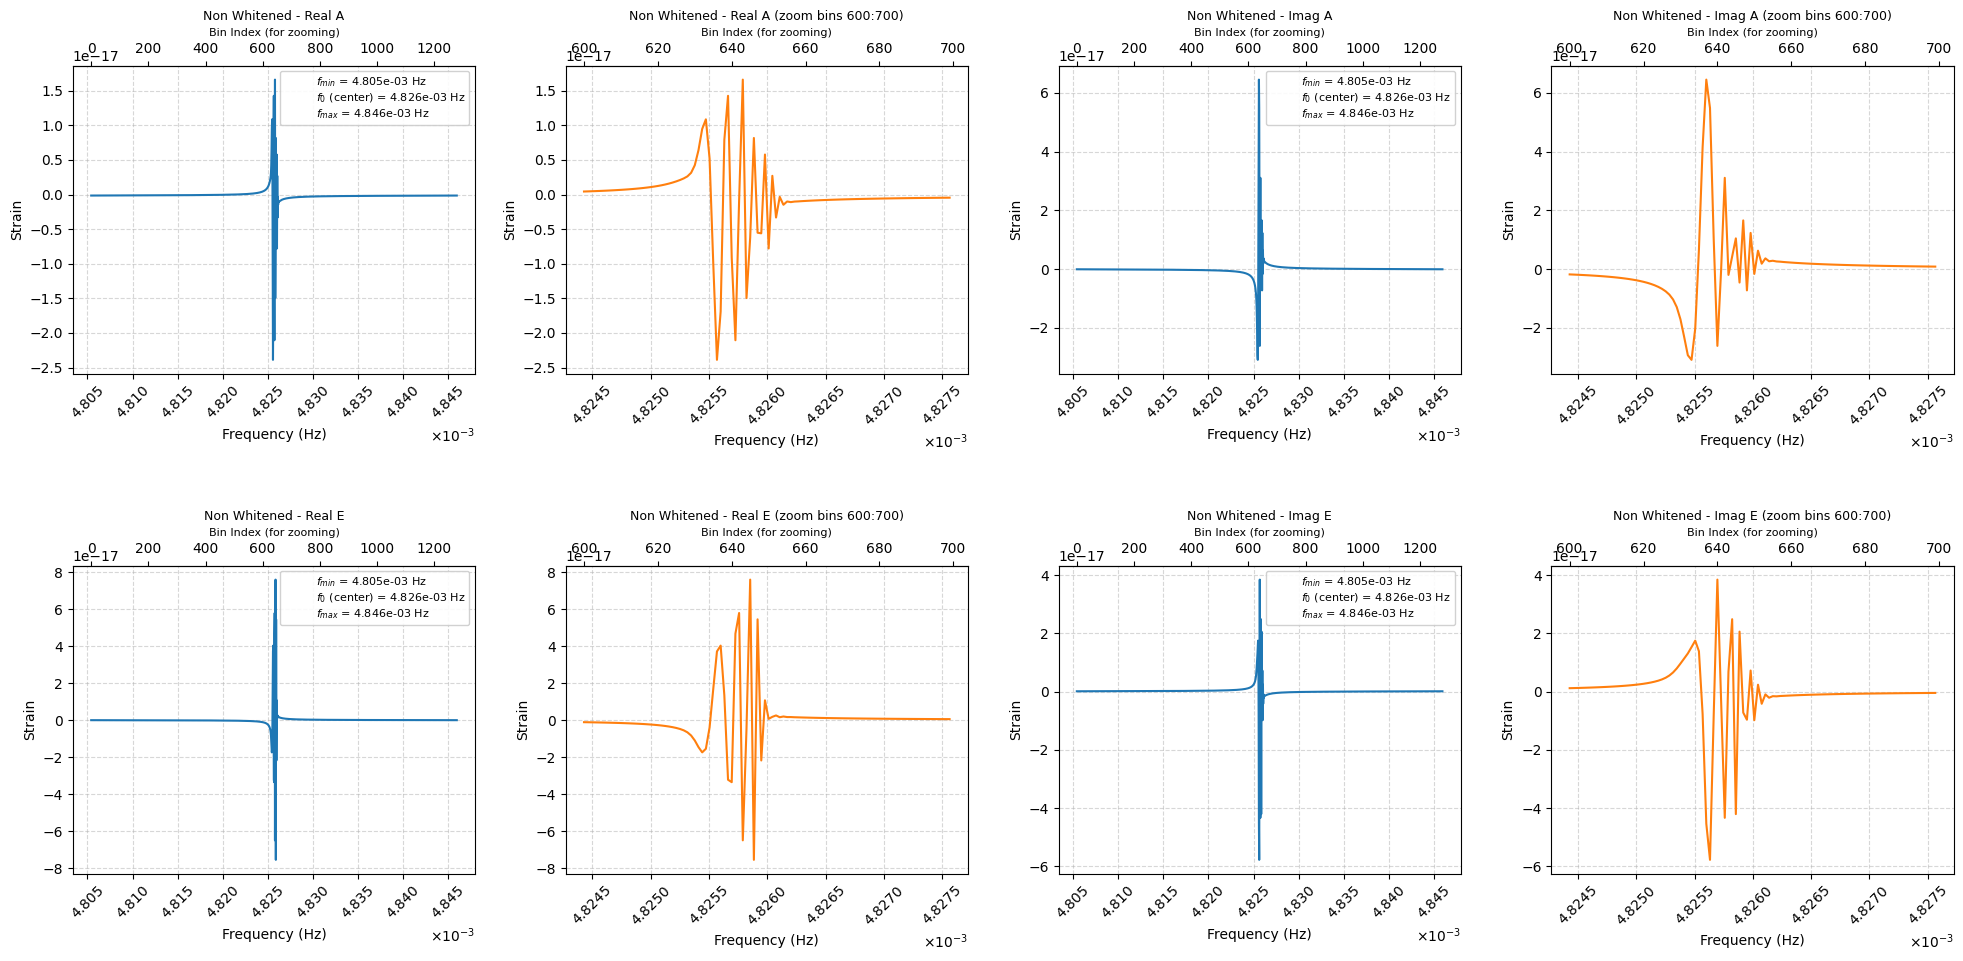

In [10]:
plot_each_channel_complex(A_real, A_imag, E_real, E_imag, df=1.0 / Tobs, start_k=gb.start_inds[0].get(), title_prefix="Non Whitened - ", zoom_start=600, zoom_end=700)

## We used to be in frequency domain (frequency/strain), lets visualize in time domain (time/strain)

In [11]:
time_domain_waveform_A = np.fft.irfft(A_complex)
time_domain_waveform_E = np.fft.irfft(E_complex)

print(f"Shape of time-domain waveform A: {time_domain_waveform_A.shape}\nShape of time-domain waveform E: {time_domain_waveform_E.shape}")

Shape of time-domain waveform A: (1, 2558)
Shape of time-domain waveform E: (1, 2558)


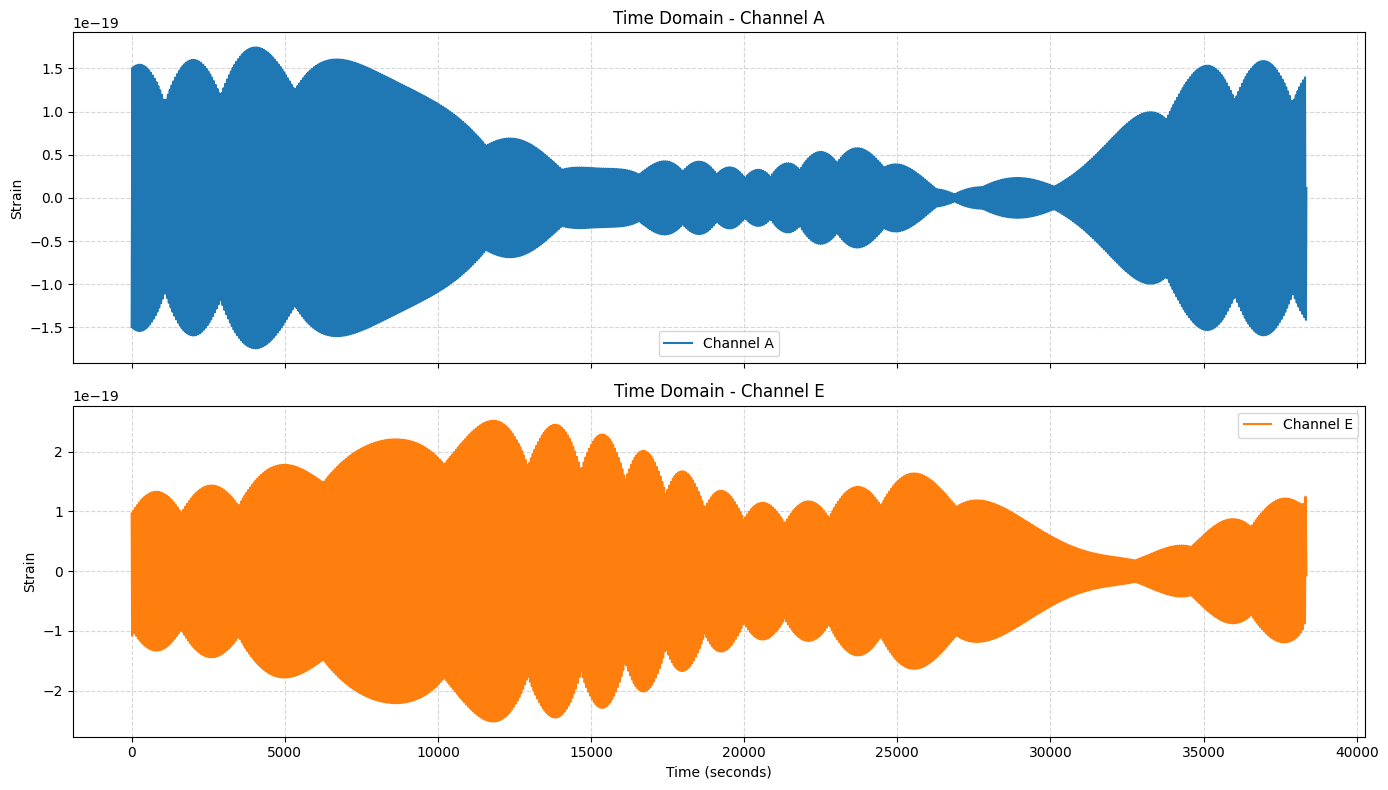

In [12]:
def plot_time_domain_channels(time_A, time_E, dt):
    """
    Plot the A and E channels in the time domain.

    time_A, time_E: numpy arrays from irfft (e.g. shape (1, N_time))
    dt: sampling interval in seconds
    """
    # Select the first sample (index 0)
    y_A = time_A[0]
    y_E = time_E[0]

    # Create the real time axis in seconds
    t = np.arange(len(y_A)) * dt

    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Plot channel A
    axs[0].plot(t, y_A, color="tab:blue", label="Channel A")
    axs[0].set_title("Time Domain - Channel A")
    axs[0].set_ylabel("Strain")
    axs[0].grid(True, linestyle="--", alpha=0.5)
    axs[0].legend()

    # Plot channel E
    axs[1].plot(t, y_E, color="tab:orange", label="Channel E")
    axs[1].set_title("Time Domain - Channel E")
    axs[1].set_xlabel("Time (seconds)")
    axs[1].set_ylabel("Strain")
    axs[1].grid(True, linestyle="--", alpha=0.5)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

# Use the function with the dt variable imported from config.py
plot_time_domain_channels(time_domain_waveform_A, time_domain_waveform_E, dt)

# With Whitening

In [13]:
from config import fixed_params, f0_center, Tobs, difficulty_factor
from gbgpu.utils.utility import get_N

N = gb.N
print(f"Original number of points (N): {N}") # 1280

df = 1.0 / Tobs
f0_width = N * df

f_min = f0_center - (f0_width / 2.0)
f_max = f0_center + (f0_width / 2.0)

print(f"Minimum frequency (f_min): {f_min:.6e} Hz")
print(f"Maximum frequency (f_max): {f_max:.6e} Hz")

k_min = int(np.round(f_min / df))
num = N 

print(f"Calculated k_min: {k_min}\nCalculated number of points (num): {num}")

Original number of points (N): 1280
Minimum frequency (f_min): 4.801419e-03 Hz
Maximum frequency (f_max): 4.841979e-03 Hz
Calculated k_min: 151524
Calculated number of points (num): 1280


In [14]:
freqs_grid = (cp.arange(num) + k_min) * df

noise = AnalyticNoise(freqs_grid, "MRDv1")
asd_A = cp.sqrt(noise.psd(option="A"))
asd_E = cp.sqrt(noise.psd(option="E"))

In [15]:
i_start = (gb.start_inds - k_min).astype(cp.int32)
i_end = i_start + gb.N
print(f"Calculated i_start: {i_start.get()}\nCalculated i_end: {i_end.get()}")

A_whitened = cp.empty((nb_samples, num), dtype=cp.complex64)
E_whitened = cp.empty((nb_samples, num), dtype=cp.complex64)

print(f"Shape of the whitened A channel: {A_whitened.shape}")

Calculated i_start: [126]
Calculated i_end: [1406]
Shape of the whitened A channel: (1, 1280)


In [16]:
for i in range(nb_samples):
    x_A = cp.zeros(num, dtype=cp.complex128)
    x_E = cp.zeros(num, dtype=cp.complex128)
    
    start = max(0, int(i_start[i]))
    end = min(num, int(i_end[i]))
    wave_start = start - int(i_start[i])
    wave_end = wave_start + (end - start)
    
    if start < end:
        x_A[start:end] = gb.A[i, wave_start:wave_end]
        x_E[start:end] = gb.E[i, wave_start:wave_end]
        
        x_A *= cp.sqrt(4 * df) / asd_A
        x_E *= cp.sqrt(4 * df) / asd_E
        
    A_whitened[i] = x_A
    E_whitened[i] = x_E

In [17]:
A_whitened_real = A_whitened.real.get()
A_whitened_imag = A_whitened.imag.get()
E_whitened_real = E_whitened.real.get()
E_whitened_imag = E_whitened.imag.get()

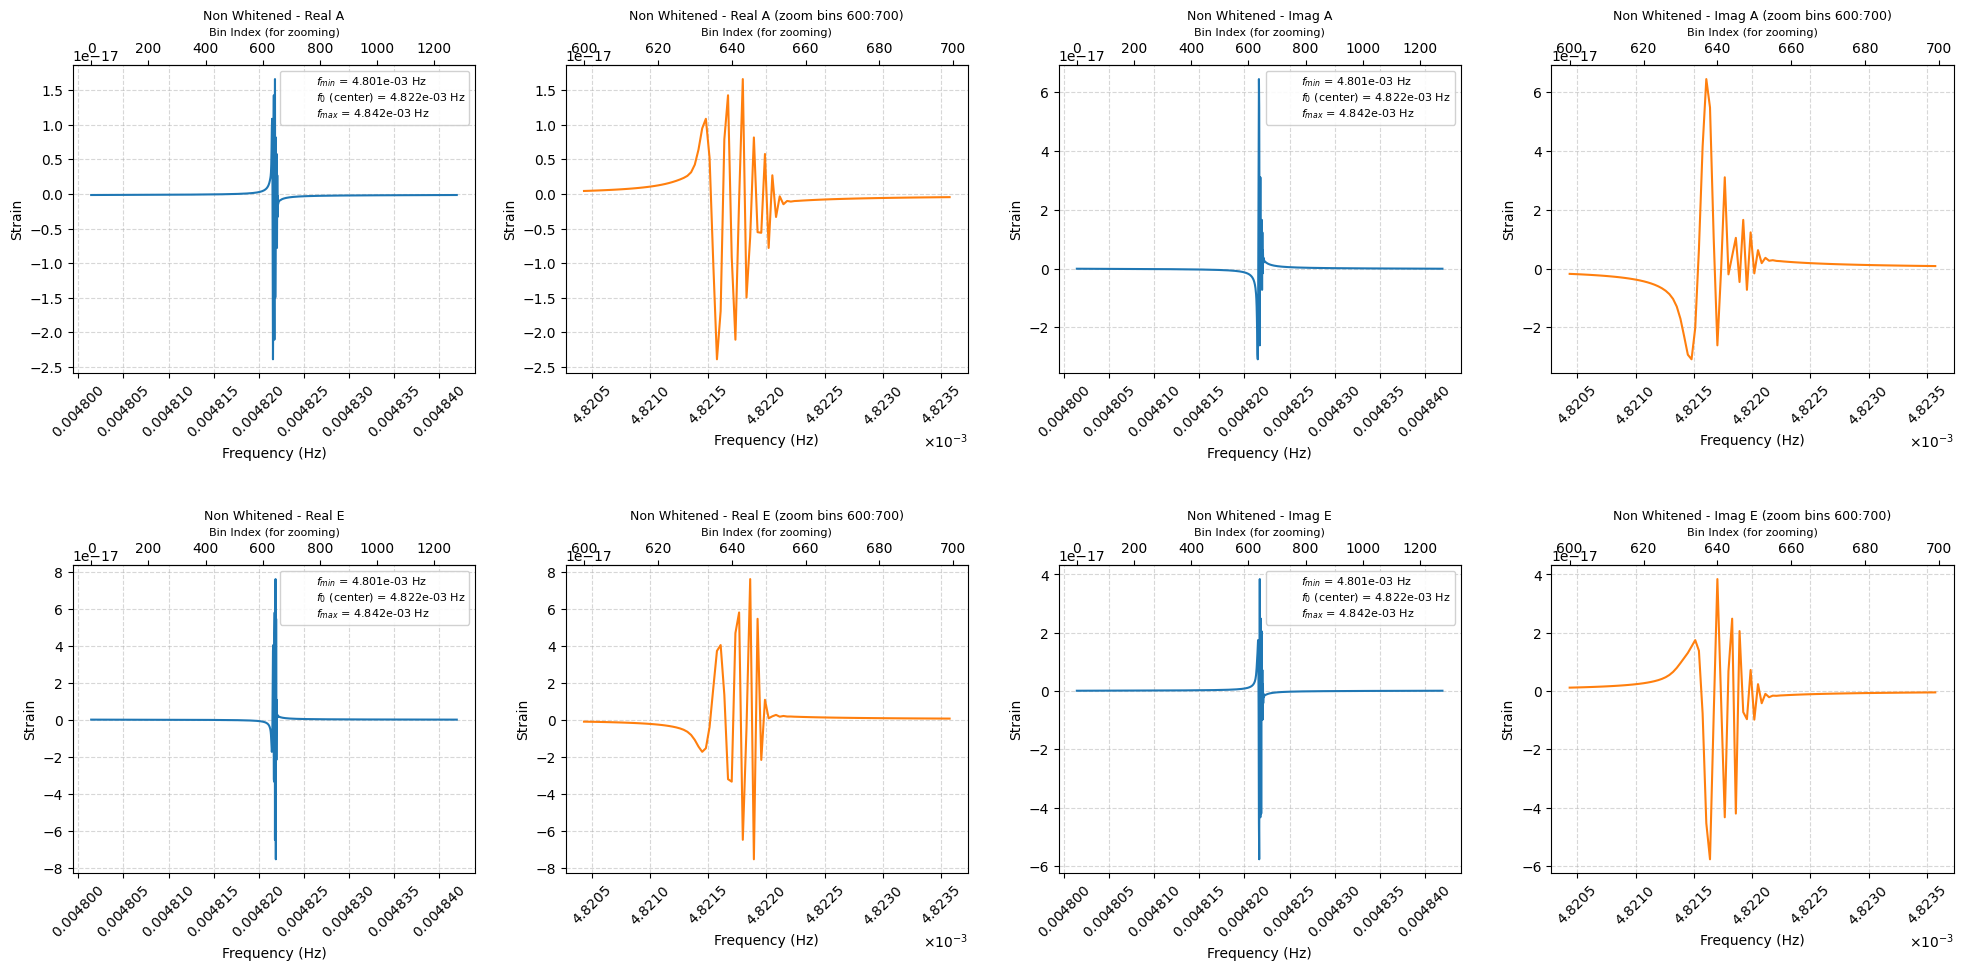

In [18]:
plot_each_channel_complex(A_real, A_imag, E_real, E_imag, df=1.0 / Tobs, start_k=k_min, title_prefix="Non Whitened - ", zoom_start=600, zoom_end=700)

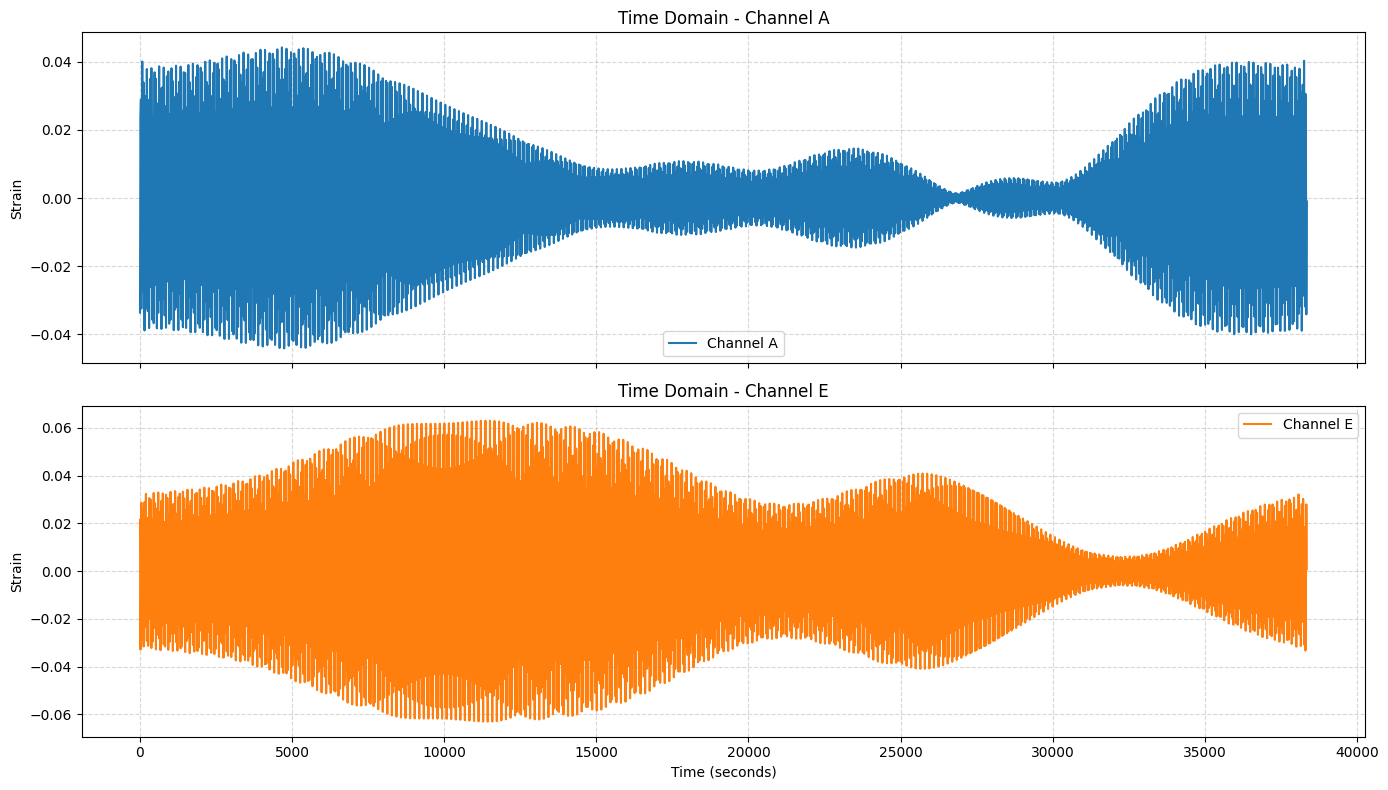

In [19]:
time_domain_whitened_A = np.fft.irfft(A_whitened.get())
time_domain_whitened_E = np.fft.irfft(E_whitened.get())

plot_time_domain_channels(time_domain_whitened_A, time_domain_whitened_E, dt)